<a href="https://colab.research.google.com/github/ithsirs/PRODIGY_ML_04/blob/main/hand_gesture_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.src.utils.numerical_utils import to_categorical
from keras.src.models.sequential import Sequential
from keras.src.saving.saving_api import load_model
from keras.src import layers
from keras.src.layers.convolutional.conv2d import Conv2D
from keras.src.layers.core.dense import Dense
from keras.src.layers.pooling.max_pooling2d import MaxPooling2D
from keras.src.layers.reshaping.flatten import Flatten
from keras.src.layers.regularization.dropout import Dropout
from google.colab import files
from keras._tf_keras.keras.preprocessing import image
from keras.src.utils.image_dataset_utils import image_dataset_from_directory


In [ ]:
!google-drive-ocamlfuse -cc

/bin/bash: line 1: google-drive-ocamlfuse: command not found


In [3]:
# prompt: fetch zip folder from google drive

from google.colab import drive
drive.mount('/content/drive')

# Replace 'path/to/your/zipfile.zip' with the actual path to your zip file in Google Drive
zip_file_path = '/content/drive/MyDrive/HandGesture.zip'

# Specify the directory where you want to extract the contents
extract_to = '/content/sample_data'

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Successfully extracted '{zip_file_path}' to '{extract_to}'")
except FileNotFoundError:
    print(f"Error: Zip file not found at '{zip_file_path}'")
except zipfile.BadZipFile:
    print(f"Error: Invalid zip file '{zip_file_path}'")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Mounted at /content/drive
Successfully extracted '/content/drive/MyDrive/HandGesture.zip' to '/content/sample_data'


In [4]:
dataset_path="/content/sample_data/HandGesture/images"

In [5]:
from keras.src.layers.normalization.batch_normalization import (
    BatchNormalization,
)
from keras.src.callbacks.early_stopping import EarlyStopping

from keras import models
from keras import layers


In [ ]:
#from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator

In [6]:
from keras.src.utils.image_dataset_utils import image_dataset_from_directory

#dataset_path = "/content/sample_data/leapGestRecog"


# Normalize images before feeding into the model
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Create the datasets and get class names before mapping
train_dataset_original = image_dataset_from_directory(
    dataset_path,
    validation_split=0.15,
    subset="training",
    seed=42,
    image_size=(64, 64),
    batch_size=32,
    color_mode="grayscale"
)

validation_dataset_original = image_dataset_from_directory(
    dataset_path,
    validation_split=0.15,
    subset="validation",
    seed=42,
    image_size=(64, 64),
    batch_size=32,
    color_mode="grayscale"
)

# Now apply mapping for normalization
train_dataset = train_dataset_original.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset_original.map(lambda x, y: (normalization_layer(x), y))



class_names = train_dataset_original.class_names
num_classes = len(class_names)

Found 5243 files belonging to 10 classes.
Using 4457 files for training.
Found 5243 files belonging to 10 classes.
Using 786 files for validation.


In [7]:
class_names

['call_me',
 'fingers_crossed',
 'okay',
 'paper',
 'peace',
 'rock',
 'rock_on',
 'scissor',
 'thumbs',
 'up']

In [ ]:
# prompt: show the attributes of training_dataset

print(dir(train_dataset))


['_GeneratorState', '__abstractmethods__', '__annotations__', '__bool__', '__class__', '__class_getitem__', '__debug_string__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__nonzero__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__tf_tracing_type__', '__weakref__', '_abc_impl', '_add_trackable_child', '_add_variable_with_custom_getter', '_apply_debug_options', '_as_serialized_graph', '_buffer_size', '_checkpoint_adapter', '_checkpoint_dependencies', '_common_args', '_consumers', '_convert_variables_to_tensors', '_copy_trackable_to_cpu', '_deferred_dependencies', '_deserialization_dependencies', '_deserialize_from_proto', '_export_to_saved_model_graph', '_flat_shapes', '_flat_structure', '_flat_types', '_func

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset= train_dataset.prefetch(buffer_size= AUTOTUNE)
validation_dataset= validation_dataset.prefetch(buffer_size= AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    #layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1)
])


In [9]:
model = tf.keras.Sequential([
    layers.Input(shape=(64, 64, 1)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    #layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])


'''model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    data_augmentation,  # includes Rescaling(1./255)

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])'''


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,794 (307.79 KB)

 Trainable params: 78,794 (307.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=5, restore_best_weights=True)]
)


Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 216ms/step - accuracy: 0.2011 - loss: 2.1427 - val_accuracy: 0.5064 - val_loss: 1.2762
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 214ms/step - accuracy: 0.5485 - loss: 1.3022 - val_accuracy: 0.8053 - val_loss: 0.6850
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.6597 - loss: 1.0110 - val_accuracy: 0.5700 - val_loss: 1.1791
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 213ms/step - accuracy: 0.7033 - loss: 0.8771 - val_accuracy: 0.8919 - val_loss: 0.4158
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.7505 - loss: 0.7405 - val_accuracy: 0.8715 - val_loss: 0.4138
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.7571 - loss: 0.6906 - val_accuracy: 0.9186 - val_loss: 0.3048
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 236ms/step - accuracy: 0.8055 - loss: 0.5910 - val_accuracy: 0.9160 - val_loss: 0.3061
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 225ms/step - accuracy: 0.8017 - loss: 0

In [ ]:
val_loss, val_accuracy = model.evaluate(validation_dataset)
print(f"\nValidation Accuracy: {val_accuracy * 100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9803 - loss: 0.1213

Validation Accuracy: 97.84%


In [11]:
# prompt: show me the accuracy of training dataset an d validation dataset

train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


Training Accuracy: 84.79%
Validation Accuracy: 95.17%


In [ ]:
model.save("hand_gesture_classifier1.keras")


In [ ]:
# Save model to file
model.save("hand_gesture_classifier.h5")
print("Model saved as gesture_classifier.h5")


Model saved as gesture_classifier.h5


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 416,288 (1.59 MB)

 Trainable params: 138,762 (542.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 277,526 (1.06 MB)

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load model
#model = load_model("gesture_classifier.h5")

# Upload an image to test
def predict():
  uploaded = files.upload()
  for fn in uploaded.keys():
      img = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)
      img = cv2.resize(img, (64, 64))
      img = img / 255.0
      img = np.expand_dims(img, axis=(0, -1))  # (1, 64, 64, 1)

      prediction = model.predict(img)
      predicted_class = np.argmax(prediction)
      #class_names = train_dataset.class_names

      print(f"Predicted Class: {class_names[predicted_class]}")

      # Optional: display image
      plt.imshow(img[0].reshape(64, 64), cmap="gray")
      plt.title(f"Predicted: {class_names[predicted_class]}")
      plt.axis("off")
      plt.show()


Saving c389f4c4-0d2e-4680-9f71-ce14ee96dc3c.jpeg to c389f4c4-0d2e-4680-9f71-ce14ee96dc3c.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
Predicted Class: scissor


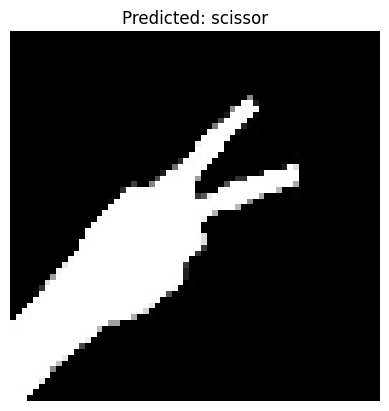

In [ ]:
predict()

Saving 4d9d9801-b50c-44ab-b5c2-9b9fb076e7ad.jpeg to 4d9d9801-b50c-44ab-b5c2-9b9fb076e7ad.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Class: rock


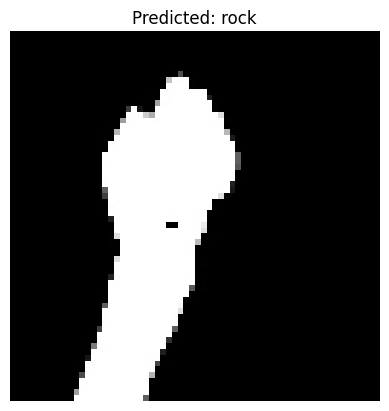

In [ ]:
predict()

Saving 74a9b81d-c8ba-433f-9645-4712f4ef9b45.jpeg to 74a9b81d-c8ba-433f-9645-4712f4ef9b45.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Class: call_me


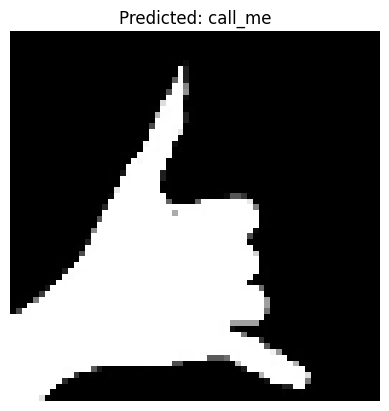

In [ ]:
predict()

Saving a082a43a-1b19-40f6-82ac-5c672be55c30.jpeg to a082a43a-1b19-40f6-82ac-5c672be55c30.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Class: fingers_crossed


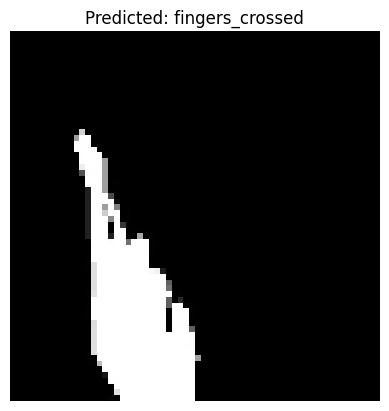

In [ ]:
predict()

Saving ea5bcc2486d5abf71dda7b70e2493a0f.jpg to ea5bcc2486d5abf71dda7b70e2493a0f.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Class: rock


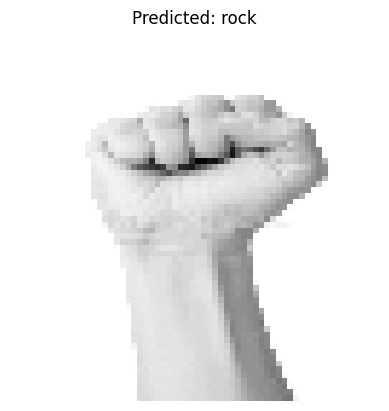

In [ ]:
predict()

Saving e30e10bb-037d-4a37-8178-0e5e93a674d7.jpeg to e30e10bb-037d-4a37-8178-0e5e93a674d7.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Class: peace


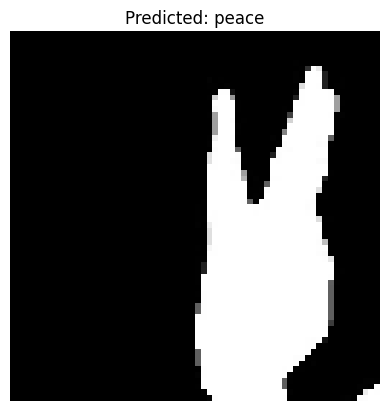

In [ ]:
predict()

Saving cb6a3c13-c595-467f-a9f2-1a4920a22b79.jpeg to cb6a3c13-c595-467f-a9f2-1a4920a22b79.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Class: thumbs


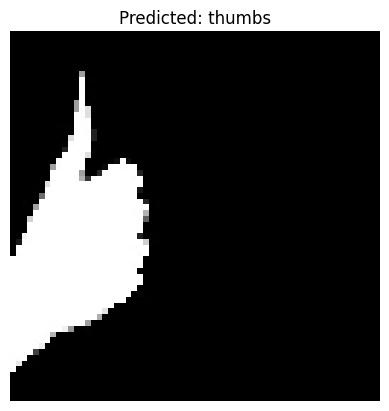

In [ ]:
predict()

In [ ]:
model = load_model("gesture_classifier.h5")

In [ ]:
import os
from collections import Counter

# Count images per class
class_counts = Counter()
for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)
    if os.path.isdir(class_path):
        class_counts[class_folder] = len(os.listdir(class_path))

print("Class distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Class distribution:
rock: 508
scissor: 527
rock_on: 531
fingers_crossed: 504
up: 504
thumbs: 537
call_me: 527
peace: 526
okay: 540
paper: 539


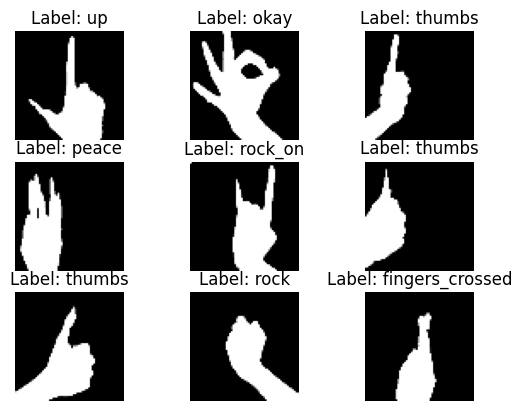

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap="gray")
        plt.title(f"Label: {class_names[labels[i]]}")
        plt.axis("off")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


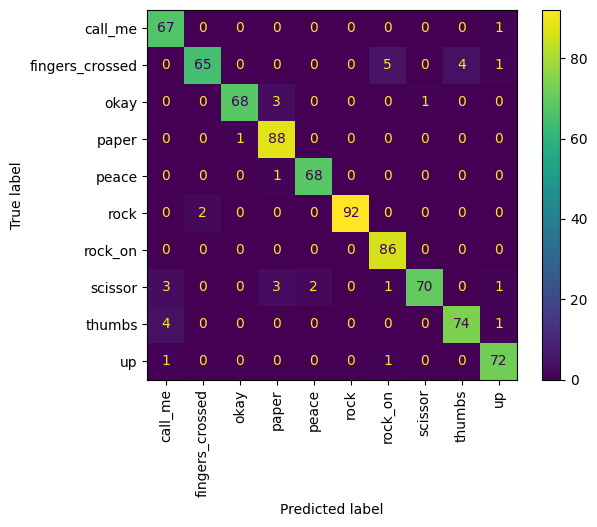

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.show()
